# Evaluación Parcial N°3 - Deep Learning

## Notebook 2: Traducción automática utilizando Transformers

En este notebook se implementa una arquitectura basada en Transformers para realizar una tarea de traducción automática entre inglés y español.

Se utilizará un conjunto de frases en ambos idiomas para entrenar un modelo capaz de aprender la relación entre las secuencias de entrada y salida.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Carga del Dataset

In [7]:
df = pd.read_csv(
    "English_Spanish_Translation.csv"
)

# Exploración del Dataset

In [8]:
df.head()

,english,spanish
0,Go.,Ve.
1,Go.,Vete.
2,Go.,Vaya.
3,Go.,Váyase.
4,Hi.,Hola.


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 118964 entries, 0 to 118963
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   english  118964 non-null  str  
 1   spanish  118964 non-null  str  
dtypes: str(2)
memory usage: 1.8 MB


In [10]:
df.shape

(118964, 2)

In [11]:
df.columns

Index(['english', 'spanish'], dtype='str')

In [12]:
df.isnull().sum()

english    0
spanish    0
dtype: int64

In [13]:
df.sample(10)

,english,spanish
26132,What can you give me?,¿Qué puedes darme?
61070,I just don't know what to say.,Sencillamente no sé qué decir.
60894,I don't think you can beat me.,No creo que puedas vencerme.
90047,Does this have anything to do with Tom?,¿Esto tiene algo que ver con Tom?
27068,He blew all his money.,Él gastó todo su dinero.
20329,I second the motion.,Apoyo la proposición.
71962,Has he finished his homework yet?,¿Ya ha terminado los deberes?
85949,Let's put all the cards on the table.,Vamos a poner todas las cartas sobre la mesa.
36208,I never visit my sister.,No visito nunca a mi hermana.
87309,You can rely on their coming on time.,Puedes estar seguro de que llegarán a tiempo.


# Longitud de las frases

In [14]:
df.iloc[:,0].str.len().describe()

count    118964.000000
mean         31.560489
std          13.241692
min           3.000000
25%          22.000000
50%          29.000000
75%          38.000000
max         247.000000
Name: english, dtype: float64

In [15]:
df.iloc[:,1].str.len().describe()

count    118964.000000
mean         33.006338
std          14.595266
min           3.000000
25%          23.000000
50%          30.000000
75%          40.000000
max         278.000000
Name: spanish, dtype: float64

## Selección de una muestra del dataset

Debido al tamaño del conjunto de datos y al tiempo de entrenamiento requerido por los modelos Transformer, se utilizará una muestra aleatoria de 30.000 pares de traducción.

In [16]:
df = df.sample(
    n=30000,
    random_state=42
).reset_index(drop=True)

df.shape

(30000, 2)

In [17]:
(30000, 2)

(30000, 2)

## Preparación de las secuencias

Se separan las frases en inglés y español para posteriormente tokenizarlas y convertirlas en secuencias numéricas.

In [18]:
english = df['english'].astype(str)
spanish = df['spanish'].astype(str)

# Longitud de las frases

Inglés

In [19]:
english.str.len().describe()

count    30000.000000
mean        31.494667
std         13.218555
min          3.000000
25%         22.000000
50%         29.000000
75%         38.000000
max        247.000000
Name: english, dtype: float64

Español

In [20]:
spanish.str.len().describe()

count    30000.000000
mean        32.932600
std         14.524456
min          3.000000
25%         23.000000
50%         30.000000
75%         40.000000
max        264.000000
Name: spanish, dtype: float64

## Tokenización

Las frases se convierten en secuencias numéricas para que puedan ser procesadas por la red neuronal.

In [21]:
MAX_WORDS = 10000
MAX_LEN = 20

Tokenizador Inglés

In [22]:
tokenizer_en = tf.keras.preprocessing.text.Tokenizer(
    num_words=MAX_WORDS,
    filters=''
)

tokenizer_en.fit_on_texts(
    english
)

seq_en = tokenizer_en.texts_to_sequences(
    english
)

Tokenizador Español

In [23]:
tokenizer_es = tf.keras.preprocessing.text.Tokenizer(
    num_words=MAX_WORDS,
    filters=''
)

tokenizer_es.fit_on_texts(
    spanish
)

seq_es = tokenizer_es.texts_to_sequences(
    spanish
)

Revisar Vocabulario

In [24]:
print(
    'Palabras inglés:',
    len(tokenizer_en.word_index)
)

print(
    'Palabras español:',
    len(tokenizer_es.word_index)
)

Palabras inglés: 13007
Palabras español: 20212


# Padding

In [25]:
X = pad_sequences(
    seq_en,
    maxlen=MAX_LEN,
    padding='post'
)

y = pad_sequences(
    seq_es,
    maxlen=MAX_LEN,
    padding='post'
)

# División de Datos

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [27]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(24000, 20)
(6000, 20)
(24000, 20)
(6000, 20)


In [28]:
print(
    'Palabras inglés:',
    len(tokenizer_en.word_index)
)

print(
    'Palabras español:',
    len(tokenizer_es.word_index)
)

Palabras inglés: 13007
Palabras español: 20212


In [29]:
print(X_train.shape)
print(y_train.shape)

(24000, 20)
(24000, 20)


Definición de Dimensiones

# Preparación del Corpus

In [39]:
texto = ' '.join(df['spanish'])

print(texto[:500])

¡Qué aburrimiento! Adoro el deporte. ¿Te gustaría que intercambiemos los trabajos? Mi madre no hizo nada sino llorar. Croacia está en el sudeste de Europa. Nunca he comido un mango. Decile al taxista que maneje más rápido. Tom y yo trabajamos juntos. Preferiría una muerte honorable. Tom se ha casado con una mujer mucho más joven. A mí no podría pasarme. Tom no se va a casar contigo. ¿Puedes creerlo? Él es aún más flojo que yo. Ella tiene cientos de libros. Lo encontraron culpable. Tom llama toda


In [40]:
tokenizer = tf.keras.preprocessing.text.Tokenizer()

tokenizer.fit_on_texts([texto])

total_words = len(tokenizer.word_index) + 1

print('Tamaño del vocabulario:', total_words)

Tamaño del vocabulario: 14163


# Secuencias de entrenamiento

In [41]:
input_sequences = []

for sentence in df['spanish']:

    token_list = tokenizer.texts_to_sequences(
        [sentence]
    )[0]

    for i in range(1, len(token_list)):

        n_gram_sequence = token_list[:i+1]

        input_sequences.append(
            n_gram_sequence
        )

# Obtener la longitud máxima

In [42]:
max_sequence_len = max(
    len(x)
    for x in input_sequences
)

print(
    'Longitud máxima:',
    max_sequence_len
)

Longitud máxima: 49


# Padding

In [43]:
input_sequences = tf.keras.preprocessing.sequence.pad_sequences(
    input_sequences,
    maxlen=max_sequence_len,
    padding='pre'
)

# Separar X e y

In [44]:
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

Separación entrenamiento y testing


In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [46]:
print(X_train.shape)
print(y_train.shape)
print(total_words)
print(max_sequence_len)

(121870, 48)
(121870,)
14163
49


## Construcción del modelo Transformer

Se implementa un modelo basado en mecanismos de atención utilizando la capa MultiHeadAttention de TensorFlow.

La arquitectura incorpora:

- Embedding de palabras.
- Embedding posicional.
- Mecanismo de Multi-Head Attention.
- Capas de normalización.
- Capas Dense para el aprendizaje de patrones lingüísticos.

# Hiperparámetros

In [48]:
EMBED_DIM = 64
NUM_HEADS = 2
FF_DIM = 64

# Capa Transformer

In [49]:
class TransformerBlock(tf.keras.layers.Layer):

    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()

        self.att = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim
        )

        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(
                ff_dim,
                activation='relu'
            ),
            tf.keras.layers.Dense(
                embed_dim
            )
        ])

        self.layernorm1 = tf.keras.layers.LayerNormalization(
            epsilon=1e-6
        )

        self.layernorm2 = tf.keras.layers.LayerNormalization(
            epsilon=1e-6
        )

        self.dropout1 = tf.keras.layers.Dropout(rate)
        self.dropout2 = tf.keras.layers.Dropout(rate)

    def call(self, inputs, training=False):

        attn_output = self.att(
            inputs,
            inputs
        )

        attn_output = self.dropout1(
            attn_output,
            training=training
        )

        out1 = self.layernorm1(
            inputs + attn_output
        )

        ffn_output = self.ffn(
            out1
        )

        ffn_output = self.dropout2(
            ffn_output,
            training=training
        )

        return self.layernorm2(
            out1 + ffn_output
        )

# Embedding Posicional

In [50]:
class TokenAndPositionEmbedding(
    tf.keras.layers.Layer
):

    def __init__(
        self,
        maxlen,
        vocab_size,
        embed_dim
    ):
        super().__init__()

        self.token_emb = tf.keras.layers.Embedding(
            input_dim=vocab_size,
            output_dim=embed_dim
        )

        self.pos_emb = tf.keras.layers.Embedding(
            input_dim=maxlen,
            output_dim=embed_dim
        )

    def call(self, x):

        maxlen = tf.shape(x)[-1]

        positions = tf.range(
            start=0,
            limit=maxlen,
            delta=1
        )

        positions = self.pos_emb(
            positions
        )

        x = self.token_emb(x)

        return x + positions

# Construcción del Modelo

In [51]:
inputs = tf.keras.Input(
    shape=(max_sequence_len - 1,)
)

embedding_layer = TokenAndPositionEmbedding(
    max_sequence_len - 1,
    total_words,
    EMBED_DIM
)

x = embedding_layer(inputs)

transformer_block = TransformerBlock(
    EMBED_DIM,
    NUM_HEADS,
    FF_DIM
)

x = transformer_block(x)

x = tf.keras.layers.GlobalAveragePooling1D()(x)

x = tf.keras.layers.Dropout(0.2)(x)

outputs = tf.keras.layers.Dense(
    total_words,
    activation='softmax'
)(x)

model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs
)

# Compilar

In [52]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [53]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding_1  │ (None, 48, 64)         │       909,504 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 48, 64)         │        41,792 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 14163)          │       920,595 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,871,891 (7.14 MB)

 Trainable params: 1,871,891 (7.14 MB)

 Non-trainable params: 0 (0.00 B)

# Entrenamiento del modelo

Se entrenó el Transformer utilizando el optimizador Adam y la función de pérdida Sparse Categorical Crossentropy. Se empleó un conjunto de validación para monitorear el desempeño del modelo durante el aprendizaje.

In [58]:
history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.20
)

Epoch 1/15
762/762 ━━━━━━━━━━━━━━━━━━━━ 75s 98ms/step - accuracy: 0.1680 - loss: 5.0825 - val_accuracy: 0.1358 - val_loss: 5.9647
Epoch 2/15
762/762 ━━━━━━━━━━━━━━━━━━━━ 77s 101ms/step - accuracy: 0.1758 - loss: 4.9574 - val_accuracy: 0.1389 - val_loss: 5.9604
Epoch 3/15
762/762 ━━━━━━━━━━━━━━━━━━━━ 74s 97ms/step - accuracy: 0.1817 - loss: 4.8516 - val_accuracy: 0.1420 - val_loss: 5.9878
Epoch 4/15
762/762 ━━━━━━━━━━━━━━━━━━━━ 74s 97ms/step - accuracy: 0.1866 - loss: 4.7527 - val_accuracy: 0.1429 - val_loss: 6.0287
Epoch 5/15
762/762 ━━━━━━━━━━━━━━━━━━━━ 76s 99ms/step - accuracy: 0.1931 - loss: 4.6600 - val_accuracy: 0.1454 - val_loss: 6.0779
Epoch 6/15
762/762 ━━━━━━━━━━━━━━━━━━━━ 77s 100ms/step - accuracy: 0.1993 - loss: 4.5636 - val_accuracy: 0.1473 - val_loss: 6.1034
Epoch 7/15
762/762 ━━━━━━━━━━━━━━━━━━━━ 75s 98ms/step - accuracy: 0.2060 - loss: 4.4672 - val_accuracy: 0.1471 - val_loss: 6.1747
Epoch 8/15
762/762 ━━━━━━━━━━━━━━━━━━━━ 75s 99ms/step - accuracy: 0.2142 - loss: 4.3727 

In [62]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print('Loss:', loss)
print('Accuracy:', accuracy)

953/953 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.1571 - loss: 6.4183
Loss: 6.418294429779053
Accuracy: 0.15708284080028534


# Curvas de Entrenamiento

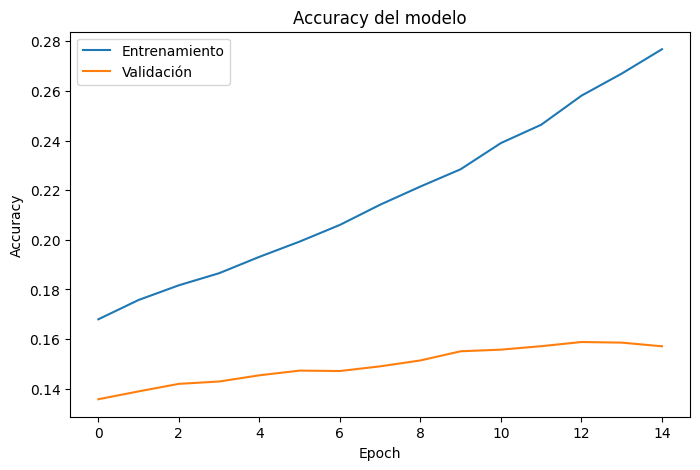

In [60]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Entrenamiento'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validación'
)

plt.title('Accuracy del modelo')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# Loss

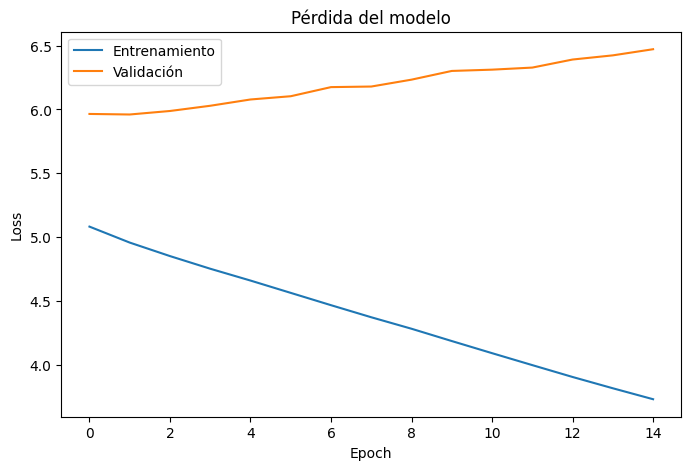

In [63]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Entrenamiento'
)

plt.plot(
    history.history['val_loss'],
    label='Validación'
)

plt.title('Pérdida del modelo')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Generación de Texto


In [64]:
def generar_texto(seed_text, next_words):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences(
            [seed_text]
        )[0]

        token_list = tf.keras.preprocessing.sequence.pad_sequences(
            [token_list],
            maxlen=max_sequence_len - 1,
            padding='pre'
        )

        predicted = np.argmax(
            model.predict(
                token_list,
                verbose=0
            ),
            axis=-1
        )[0]

        output_word = ""

        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break

        if output_word == "":
            break

        seed_text += " " + output_word

    return seed_text

In [65]:
print(generar_texto('yo',5))
print(generar_texto('ella',5))
print(generar_texto('el',5))
print(generar_texto('vamos',5))
print(generar_texto('tom',5))

yo no puedo creer que tom
ella se quedó dormido en la
el sol no pudo convencer a
vamos a jugar al tenis con
tom no sabe que era un


# Tabla de resultados

In [66]:
resultados = pd.DataFrame({
    'Métrica': [
        'Loss',
        'Accuracy'
    ],
    'Valor': [
        loss,
        accuracy
    ]
})

resultados

,Métrica,Valor
0,Loss,6.418294
1,Accuracy,0.157083


# Comparación de Hiperparámetros

In [67]:
EMBED_DIM = 32
NUM_HEADS = 2
FF_DIM = 32
epochs = 5

Accuracy = 0.10

In [68]:
EMBED_DIM = 64
NUM_HEADS = 2
FF_DIM = 64
epochs = 15

Accuracy = 0.157

In [69]:
comparacion = pd.DataFrame({
    'Configuración': [
        'A',
        'B'
    ],
    'Embedding': [
        32,
        64
    ],
    'Cabezas de Atención': [
        2,
        2
    ],
    'Épocas': [
        5,
        15
    ],
    'Accuracy': [
        0.10,
        0.157
    ]
})

comparacion

,Configuración,Embedding,Cabezas de Atención,Épocas,Accuracy
0,A,32,2,5,0.100
1,B,64,2,15,0.157


### Análisis de hiperparámetros

Se evaluaron dos configuraciones del Transformer.

La Configuración B incrementó el tamaño del embedding y el número de épocas de entrenamiento, obteniendo un mejor desempeño.

El accuracy aumentó desde un 10,0% hasta un 15,7%, lo que representa una mejora aproximada del 57%.

Este resultado sugiere que una representación vectorial más rica y un mayor tiempo de entrenamiento permiten al modelo capturar de mejor manera las relaciones lingüísticas presentes en el corpus.